# SpiderNet tutorial: Pancancer example

This notebook demonstrates the **core SpiderNet workflow** on the **Pancancer dataset** and can be used as a **template for applying SpiderNet to a new dataset**.

## Core pipeline
1. **Edit the dataset setup cell**  
   Specify the **input paths**, **resource files**, and key dataset-specific settings.

2. **Check paths and AnnData fields**  
   Verify that all required files, metadata fields, and **AnnData structure** are correctly configured before running the pipeline.

3. **Preprocess the raw data**  
   Convert the input data into the **SpiderNet input format** needed for downstream model training.

4. **Train the model**  
   Run **SpiderNet training** to learn latent **meta-interactions (MIs)** and communication-related representations.

5. **Infer and export results**  
   Generate and save the main outputs, including **MI factors**, **gene / LR loadings**, and other downstream analysis files.

## Optional analyses
- **MI correlation**
- **LR pathway enrichment**
- **sender--receiver cell-type enrichment**

## Before you start

Under `DATA_ROOT`, keep an `adata/` folder with one `.h5ad` file per sample or batch.

Each `.h5ad` should contain:
- Spatial coordinates: `adata.obsm['spatial']`
- Sample IDs: `adata.obs[SAMPLE_ID_COL]`
- Pre-determined cell type labels: `adata.obs[CELL_TYPE_COL]`
- gene symbols in `adata.var_names` (for example `MYC`, `TP53`)



## 0. Dataset setup (edit this cell first)

Put the dataset-specific settings here. In most cases, this is the main cell you need to edit when switching to a new dataset.


In [1]:
from pathlib import Path

import numpy as np

# Paths
DATA_ROOT = Path("D:/SpiderNet/Data/Pancancer") ## path to raw input data
OUTPUT_ROOT = Path("D:/SpiderNet/Results/Pancancer") ## path to save outputs and results

# Dataset-specific fields
SPECIES = "human"          # "human" or "mouse"
SAMPLE_ID_COL = "SampleID" # column in adata.obs
CELL_TYPE_COL = "celltype_final" # column in adata.obs
SPATIAL_KEY = "spatial"    # key in adata.obsm

# Preprocessing parameters
N_HVG = 1000 # number of highly variable genes for training (default: 1000)
N_HVG_LR = 2000 # number of highly variable genes for ligand-receptor filtering (default: 2000)
NUM_NEIGHBORS = 5 # number of neighbors for cell pair construction (default: 10 for small datasets, 5 for large datasets)

# Training parameters
DIM_ENVIR = 11 # number of latent MI dimensions
N_JOBS = 5 # number of parallel CPU cores for initialization and training
MAX_EPOCH = 20000 # maximum number of training epochs (default: 20000 for smaller datasets, 10000 for larger datasets)

VERSION = "V1"

import json
# Create config dict
config = {
    "DATA_ROOT": str(DATA_ROOT),
    "OUTPUT_ROOT": str(OUTPUT_ROOT),
    "SPECIES": SPECIES,
    "SAMPLE_ID_COL": SAMPLE_ID_COL,
    "CELL_TYPE_COL": CELL_TYPE_COL,
    "SPATIAL_KEY": SPATIAL_KEY,
    "N_HVG": N_HVG,
    "N_HVG_LR": N_HVG_LR,
    "NUM_NEIGHBORS": NUM_NEIGHBORS,
    "DIM_ENVIR": DIM_ENVIR,
    "N_JOBS": N_JOBS,
    "MAX_EPOCH": MAX_EPOCH,
    "VERSION": VERSION,
}

# Make sure output folder exists
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

# Save to OUTPUT_ROOT
config_path = OUTPUT_ROOT / "config.json"
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config, f, indent=4)

print(f"Config saved to: {config_path}")



Config saved to: D:\SpiderNet\Results\Pancancer\config.json


## 1. Imports and device setup

Load SpiderNet utilities and choose CPU or CUDA.


In [2]:
import json

from SpiderNet.utils import *
from SpiderNet.config import *
import subprocess
import sys

cuda_available = torch.cuda.is_available()
if cuda_available:
    device = "cuda"
else:
    device = "cpu"
print(f"Using device: {device}")


Using device: cuda


## 2. Build paths from the dataset setup

This cell uses the values from the dataset setup cell above.


In [3]:
paths = PathConfig(
    data_root=DATA_ROOT,
    output_root=OUTPUT_ROOT,
    species=SPECIES,
    version=VERSION,
)

paths


PathConfig(data_root=WindowsPath('D:/SpiderNet/Data/Pancancer'), output_root=WindowsPath('D:/SpiderNet/Results/Pancancer'), species='human', cellchat_db=WindowsPath('D:/SpiderNet/SpiderNet_proj/SpiderNet_Project/SpiderNet/resources/Human_LR_pairs_Cellchatdb.csv'), scseqcomm_db=WindowsPath('D:/SpiderNet/SpiderNet_proj/SpiderNet_Project/SpiderNet/resources/Human_LR_pairs_scSeqComm.csv'), version='V1')

In [4]:
##Copy sample IDs and cell type labels to the expected obs fields if needed, and check that the expected fields are present.
import scanpy as sc

adata_dir = Path(DATA_ROOT) / "adata"
sample_files = sorted(adata_dir.glob("*.h5ad"))

updated_rows = []

for sample_path in sample_files:
    adata_i = sc.read_h5ad(sample_path)

    ok_sample_id_col = SAMPLE_ID_COL in adata_i.obs.columns
    ok_cell_type_col = CELL_TYPE_COL in adata_i.obs.columns

    if ok_sample_id_col:
        adata_i.obs["SAMPLE_ID"] = adata_i.obs[SAMPLE_ID_COL].copy()
    if ok_cell_type_col:
        adata_i.obs["CELL_TYPE"] = adata_i.obs[CELL_TYPE_COL].copy()

    adata_i.write_h5ad(sample_path)

    updated_rows.append({
        "file": sample_path.name,
        f"has obs['{SAMPLE_ID_COL}']": ok_sample_id_col,
        f"has obs['{CELL_TYPE_COL}']": ok_cell_type_col,
        f"created obs['SAMPLE_ID']": ok_sample_id_col,
        f"created obs['CELL_TYPE']": ok_cell_type_col,
    })

display(pd.DataFrame(updated_rows))

C:\Users\junji\miniconda3\envs\SpiderNet_env\Lib\site-packages\louvain\__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


,file,has obs['SampleID'],has obs['celltype_final'],created obs['SAMPLE_ID'],created obs['CELL_TYPE']
0,HumanBreastCancerPatient1_subslice_0_annotated...,False,True,False,True
1,HumanBreastCancerPatient1_subslice_1_annotated...,False,True,False,True
2,HumanBreastCancerPatient1_subslice_2_annotated...,False,True,False,True
3,HumanBreastCancerPatient1_subslice_3_annotated...,False,True,False,True
4,HumanBreastCancerPatient1_subslice_4_annotated...,False,True,False,True
5,HumanColonCancerPatient2_subslice_0_annotated....,False,True,False,True
6,HumanColonCancerPatient2_subslice_1_annotated....,False,True,False,True
7,HumanColonCancerPatient2_subslice_2_annotated....,False,True,False,True
8,HumanColonCancerPatient2_subslice_3_annotated....,False,True,False,True
9,HumanColonCancerPatient2_subslice_4_annotated....,False,True,False,True


### Check paths and AnnData fields

Use the next cell to confirm that paths exist and the first `.h5ad` file has the expected fields.


In [5]:
adata_dir = Path(DATA_ROOT) / "adata"
sample_files = sorted(adata_dir.glob("*.h5ad"))
sample_path = sample_files[0] if sample_files else None

rows = [
    {"item": "DATA_ROOT", "value": str(DATA_ROOT), "ok": Path(DATA_ROOT).exists()},
    {"item": "OUTPUT_ROOT", "value": str(OUTPUT_ROOT), "ok": Path(OUTPUT_ROOT).exists()},
    {"item": "CellChat DB", "value": str(paths.cellchat_db), "ok": Path(paths.cellchat_db).exists()},
    {"item": "scSeqComm DB", "value": str(paths.scseqcomm_db), "ok": Path(paths.scseqcomm_db).exists()},
    {"item": "adata folder", "value": str(adata_dir), "ok": adata_dir.exists()},
    {"item": "number of .h5ad files", "value": len(sample_files), "ok": len(sample_files) > 0},
]

if sample_path is not None:
    adata_example = sc.read_h5ad(sample_path, backed="r")
    rows.extend([
        {"item": "example file", "value": sample_path.name, "ok": True},
        {"item": f"obs['{SAMPLE_ID_COL}']", "value": SAMPLE_ID_COL, "ok": SAMPLE_ID_COL in adata_example.obs.columns},
        {"item": f"obs['{CELL_TYPE_COL}']", "value": CELL_TYPE_COL, "ok": CELL_TYPE_COL in adata_example.obs.columns},
        {"item": f"obsm['{SPATIAL_KEY}']", "value": SPATIAL_KEY, "ok": SPATIAL_KEY in adata_example.obsm_keys()},
    ])
    adata_example.file.close()
else:
    rows.append({"item": "example file", "value": "No .h5ad file found", "ok": False})

display(pd.DataFrame(rows))


C:\Users\junji\AppData\Local\Temp\ipykernel_12348\1599764295.py:20: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  {"item": f"obsm['{SPATIAL_KEY}']", "value": SPATIAL_KEY, "ok": SPATIAL_KEY in adata_example.obsm_keys()},


,item,value,ok
0,DATA_ROOT,D:\SpiderNet\Data\Pancancer,True
1,OUTPUT_ROOT,D:\SpiderNet\Results\Pancancer,True
2,CellChat DB,D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\...,True
3,scSeqComm DB,D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\...,True
4,adata folder,D:\SpiderNet\Data\Pancancer\adata,True
5,number of .h5ad files,40,True
6,example file,HumanBreastCancerPatient1_subslice_0_annotated...,True
7,obs['SampleID'],SampleID,False
8,obs['celltype_final'],celltype_final,True
9,obsm['spatial'],spatial,True


## 3. Build preprocessing and training configs

These values are taken from the dataset setup cell.


In [6]:
preprocess_cfg = PreprocessConfig(
    n_hvg=N_HVG,
    n_hvg_lr=N_HVG_LR,
    num_neighbors=NUM_NEIGHBORS
)

train_cfg = TrainingConfig(
    dim_envir=DIM_ENVIR,
    n_jobs=N_JOBS,
    max_epoch=MAX_EPOCH,
    version=VERSION
)

run_dirs = paths.ensure_dirs(
    dim_envir=train_cfg.dim_envir
)
print(run_dirs)

with open(paths.output_root / "run_dirs.json", "w", encoding="utf-8") as handle:
    json.dump({k: str(v) for k, v in run_dirs.items()}, handle, indent=2)


{'run_dir': WindowsPath('D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11'), 'model_dir': WindowsPath('D:/SpiderNet/Results/Pancancer/V1/SpiderNet_Result_dim11/Model')}


In [7]:
preprocess_cfg

PreprocessConfig(n_hvg=1000, n_hvg_lr=2000, num_neighbors=5)

## 4. Preprocess raw data and load processed data

Convert raw input data into SpiderNet-ready objects and save them to the run directory.


In [8]:
subprocess.run(
    [
        sys.executable,
        "-m",
        "SpiderNet.dataloading_Pancancer",
        str(paths.data_root),
        str(preprocess_cfg.n_hvg),
        str(preprocess_cfg.n_hvg_lr),
        str(paths.cellchat_db),
        str(paths.scseqcomm_db),
        str(preprocess_cfg.num_neighbors),
        str(paths.output_root),
        str(str(run_dirs['run_dir']) + "/"),
        str("None"),
        str("None"),
        str("adata")
    ],
    check=True,
)


CompletedProcess(args=['C:\\Users\\junji\\miniconda3\\envs\\SpiderNet_env\\python.exe', '-m', 'SpiderNet.dataloading_Pancancer', 'D:\\SpiderNet\\Data\\Pancancer', '1000', '2000', 'D:\\SpiderNet\\SpiderNet_proj\\SpiderNet_Project\\SpiderNet\\resources\\Human_LR_pairs_Cellchatdb.csv', 'D:\\SpiderNet\\SpiderNet_proj\\SpiderNet_Project\\SpiderNet\\resources\\Human_LR_pairs_scSeqComm.csv', '5', 'D:\\SpiderNet\\Results\\Pancancer', 'D:\\SpiderNet\\Results\\Pancancer\\V1\\SpiderNet_Result_dim11/', 'None', 'None', 'adata'], returncode=0)

Reloads processed objects for training and downstream analysis.

Check that the number of batches, LR pairs, and training genes is reasonable.


In [9]:
from SpiderNet.io import load_processed_data
processed = load_processed_data(run_dirs["run_dir"])

print("Number of batches:", len(processed.spidernet_data))
print("Number of LR pairs:", len(processed.lr_list))
print("Number of training genes:", processed.genenames_train.shape[0])


Number of batches: 40
Number of LR pairs: 106
Number of training genes: 500


Check whether the processed data are non-empty and internally consistent before training.


In [10]:
summary_rows = []
for i in range(len(processed.adata_list)):
    adata_i = processed.adata_list[i]
    edge_index_max = torch.max(processed.spidernet_data[i]["edge_index"]).cpu().item()
    summary_rows.append(
        {
            "batch_index": i,
            "n_cells": adata_i.n_obs,
            "n_genes": adata_i.n_vars,
            "edge_index_max": edge_index_max,
            "edge_index_matches_n_cells": adata_i.n_obs == (edge_index_max + 1),
        }
    )

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

issues = []
if len(processed.spidernet_data) == 0:
    issues.append("No processed batches were loaded.")
if len(processed.lr_list) == 0:
    issues.append("No ligand-receptor pairs were retained.")
if processed.genenames_train.shape[0] == 0:
    issues.append("No training genes were retained.")
if not summary_df["edge_index_matches_n_cells"].all():
    issues.append("At least one batch has an edge index / cell-count mismatch.")

if issues:
    print("Sanity check flagged the following issues:")
    for issue in issues:
        print("-", issue)
else:
    print("Sanity checks passed. The processed data appear internally consistent.")


,batch_index,n_cells,n_genes,edge_index_max,edge_index_matches_n_cells
0,0,47423,500,47422,True
1,1,40606,500,40605,True
2,2,42502,500,42501,True
3,3,31827,500,31826,True
4,4,37125,500,37124,True
5,5,45114,500,45113,True
6,6,34468,500,34467,True
7,7,53402,500,53401,True
8,8,37891,500,37890,True
9,9,39533,500,39532,True


Sanity checks passed. The processed data appear internally consistent.


## 5. Build and train the SpiderNet model

Initialize the model using the processed data and training settings.


In [11]:
from SpiderNet.api import build_model
model = build_model(
    processed=processed,
    train_cfg=train_cfg,
    device=device,
)

print(model)


Number of GPUs available: 1
GPU 0: NVIDIA GeForce RTX 4070
SpiderNet_model(
  (dropout_fun): Dropout(p=0.1, inplace=False)
  (Relu): ReLU()
  (Sigmoid): Sigmoid()
  (enc_factor_envir_pre_receiver): Sequential(
    (0): Linear(in_features=500, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): Tanh()
  )
  (enc_factor_envir_pre_sender): Sequential(
    (0): Linear(in_features=500, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): Tanh()
  )
  (enc_factor_envir): Sequential(
    (0): Linear(in_features=128, out_features=128, bias=True)
    (1): Tanh()
    (2): Linear(in_features=128, out_features=11, bias=True)
  )
)


Runs model training and saves checkpoints.

In [12]:
from SpiderNet.api import run_training
model = run_training(
    model=model,
    processed=processed,
    train_cfg=train_cfg,
    model_dir=run_dirs["model_dir"],
    device=device,
)


Loading existing trained model...


### Extract the inferred meta-interactions and loadings

This step generates the main outputs:
- MI activities
- LR loadings
- sender loadings
- receiver loadings


In [13]:
from SpiderNet.api import infer_meta_interactions, normalize_outputs
results = infer_meta_interactions(model=model, processed=processed)
results = normalize_outputs(results)

print("Factor_envir shape:", results["factor_envir"].shape)
print("LR loading shape:", results["loading_lr"].shape)
print("Receiver loading shape:", results["loading_receiver"].shape)
print("Sender loading shape:", results["loading_sender"].shape)


Factor_envir shape: (6201650, 11)
LR loading shape: (11, 106)
Receiver loading shape: (11, 500)
Sender loading shape: (11, 500)


Saves the main outputs and config files.

In [14]:
from SpiderNet.api import export_results
export_results(
    results=results,
    processed=processed,
    output_dir=run_dirs["run_dir"],
)

# Save the model and preprocessing configurations for reproducibility.
with open(run_dirs["model_dir"] / "SpiderNet_model_config.json", "w", encoding="utf-8") as handle:
    json.dump(train_cfg.to_dict(), handle, indent=2)

with open(run_dirs["model_dir"] / "SpiderNet_preprocess_config.json", "w", encoding="utf-8") as handle:
    json.dump(preprocess_cfg.to_dict(), handle, indent=2)

print(f"Results saved to: {run_dirs['run_dir']}")


Results saved to: D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11


## Key output files

Most important outputs:
- `Factor_envir_use.npy`
- `loading_LR_use.npy`
- `loading_sender_use.npy`
- `loading_receiver_use.npy`

Check these before running optional analyses.


## Optional downstream analyses

The remaining sections help interpret results, but are not required to run SpiderNet on a new dataset.


## Optional 1. MI correlation analysis

Explores relationships among inferred meta-interactions.


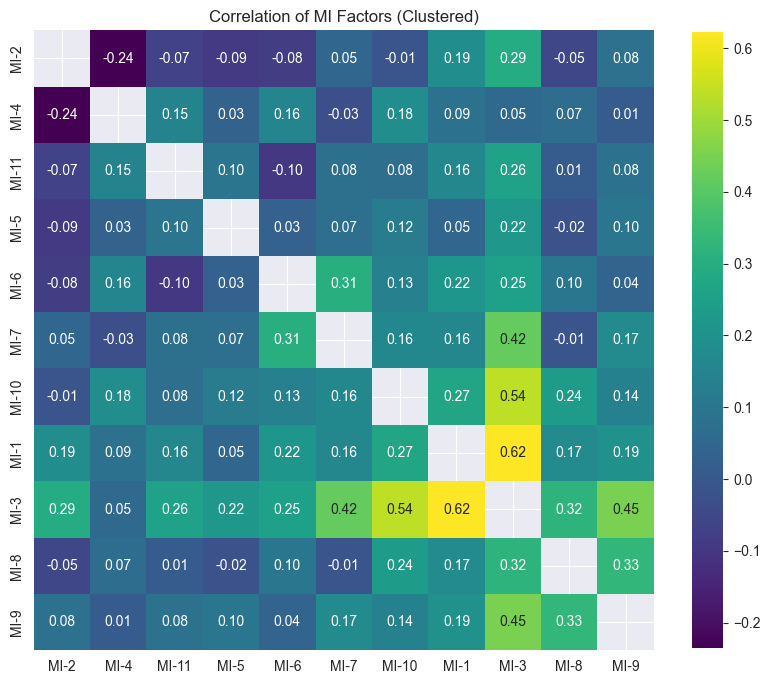

✅ Saved heatmap to D:\SpiderNet\Results\Pancancer\V1\SpiderNet_Result_dim11\MI_correlation_heatmap_clustered.png


In [15]:
from SpiderNet.analysis import MI_correlation

mi_results = MI_correlation(run_dirs['run_dir'], run_dirs['run_dir'] / "Factor_envir_use.npy", show=True)


## Optional 2. LR loading-based pathway enrichment

Interprets each MI using ligand--receptor pathway content.


ANGPT: 1 LR pairs
CCL: 7 LR pairs
PD-L1: 1 LR pairs
CD40: 3 LR pairs
CD70: 1 LR pairs
CD80: 1 LR pairs
CD86: 1 LR pairs
CDH: 1 LR pairs
CDH1: 2 LR pairs
CDH5: 1 LR pairs
COLLAGEN: 6 LR pairs
CSF: 1 LR pairs
CXCL: 9 LR pairs
EGF: 2 LR pairs
FGF: 6 LR pairs
FN1: 4 LR pairs
MHC-I: 4 LR pairs
MHC-II: 6 LR pairs
ICAM: 5 LR pairs
ITGB2: 2 LR pairs
LAMININ: 4 LR pairs
GALECTIN: 1 LR pairs
NCAM: 2 LR pairs
PDL2: 1 LR pairs
PDGF: 5 LR pairs
PECAM1: 1 LR pairs
CD45: 2 LR pairs
SPP1: 3 LR pairs
TGFb: 9 LR pairs
TENASCIN: 1 LR pairs
VCAM: 3 LR pairs
VTN: 1 LR pairs
WNT: 8 LR pairs
ncWNT: 1 LR pairs


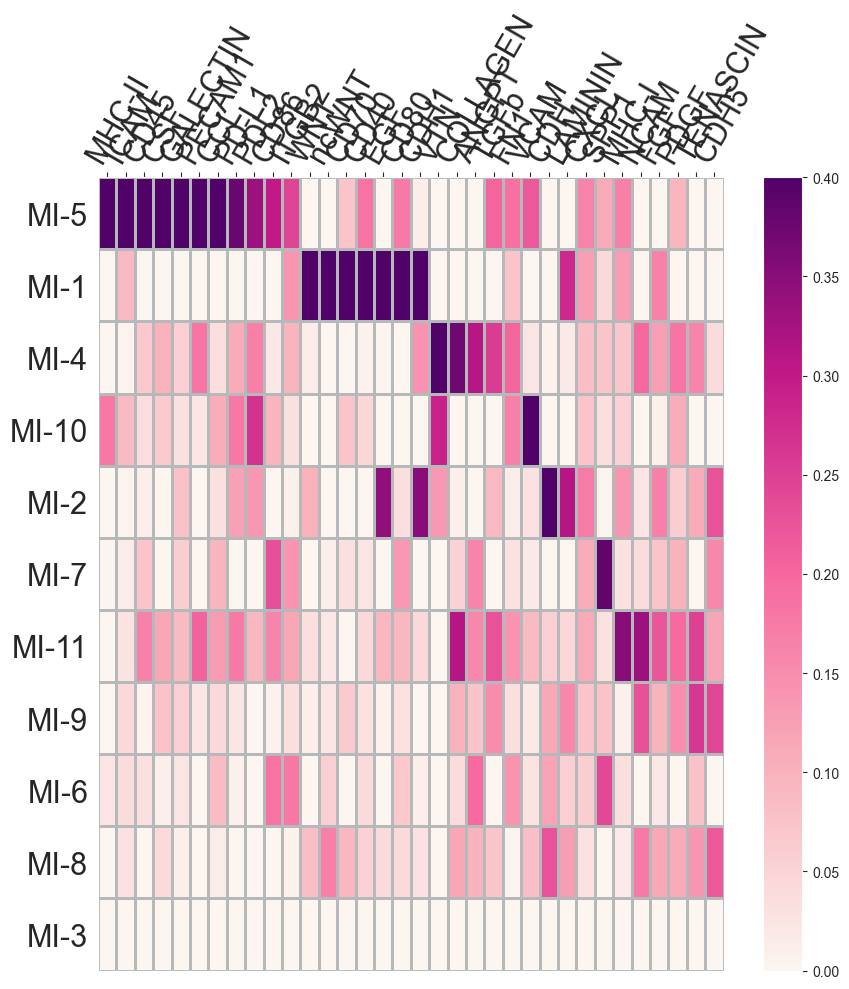

{'loading_LR_use_df':        ANGPT2 -> ITGA5+ITGB1  CCL3 -> CCR1  CCL3 -> CCR5  CCL5 -> CCR1  \
 MI-1            0.000000e+00  0.000000e+00  0.000000e+00  0.000000e+00   
 MI-2            0.000000e+00  1.991461e-02  1.599839e-02  0.000000e+00   
 MI-3            6.626275e-08  3.336721e-08  1.820607e-08  5.408114e-08   
 MI-4            2.005606e-01  1.415591e-02  1.551555e-02  2.241822e-02   
 MI-5            0.000000e+00  1.497701e-01  6.544755e-02  5.901657e-01   
 MI-6            1.283539e-01  3.670269e-02  1.400368e-02  5.372263e-02   
 MI-7            1.047787e-01  6.238844e-02  2.811786e-02  4.943667e-02   
 MI-8            6.404980e-02  0.000000e+00  0.000000e+00  3.830322e-02   
 MI-9            4.763382e-02  2.531332e-02  7.498516e-03  3.300998e-02   
 MI-10           0.000000e+00  3.881872e-02  3.310949e-02  7.252821e-02   
 MI-11           1.026370e-01  5.000481e-02  2.514401e-02  1.073571e-01   
 
        CCL5 -> CCR4  CCL5 -> CCR5  CCL7 -> CCR1  CCL8 -> CCR1  CD274 -> PDCD

In [16]:
from SpiderNet.analysis import LRLoading_enrichment
LRLoading_enrichment(
    loading_LR_use_path=run_dirs['run_dir'] / "loading_LR_use.npy",
    lr_list_path=run_dirs['run_dir'] / "LR_list.pkl",
    lr_list_cellchatdb_path=run_dirs['run_dir'] / "LR_list_cellchatdb.pkl",
    lr_meta_cellchatdb_path=run_dirs['run_dir'] / "LR_meta_cellchatdb.pkl",
    Factor_envir_use_path=run_dirs['run_dir'] / "Factor_envir_use.npy",
    file_savepath_main=run_dirs['run_dir'],
    show=True
)


## Optional 3. Sender-cell-type--receiver-cell-type interaction analysis

Summarizes MI enrichment across sender--receiver cell-type pairs.


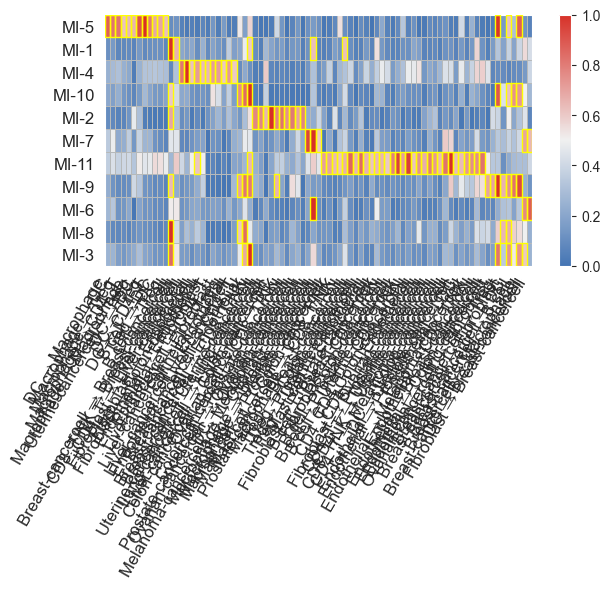

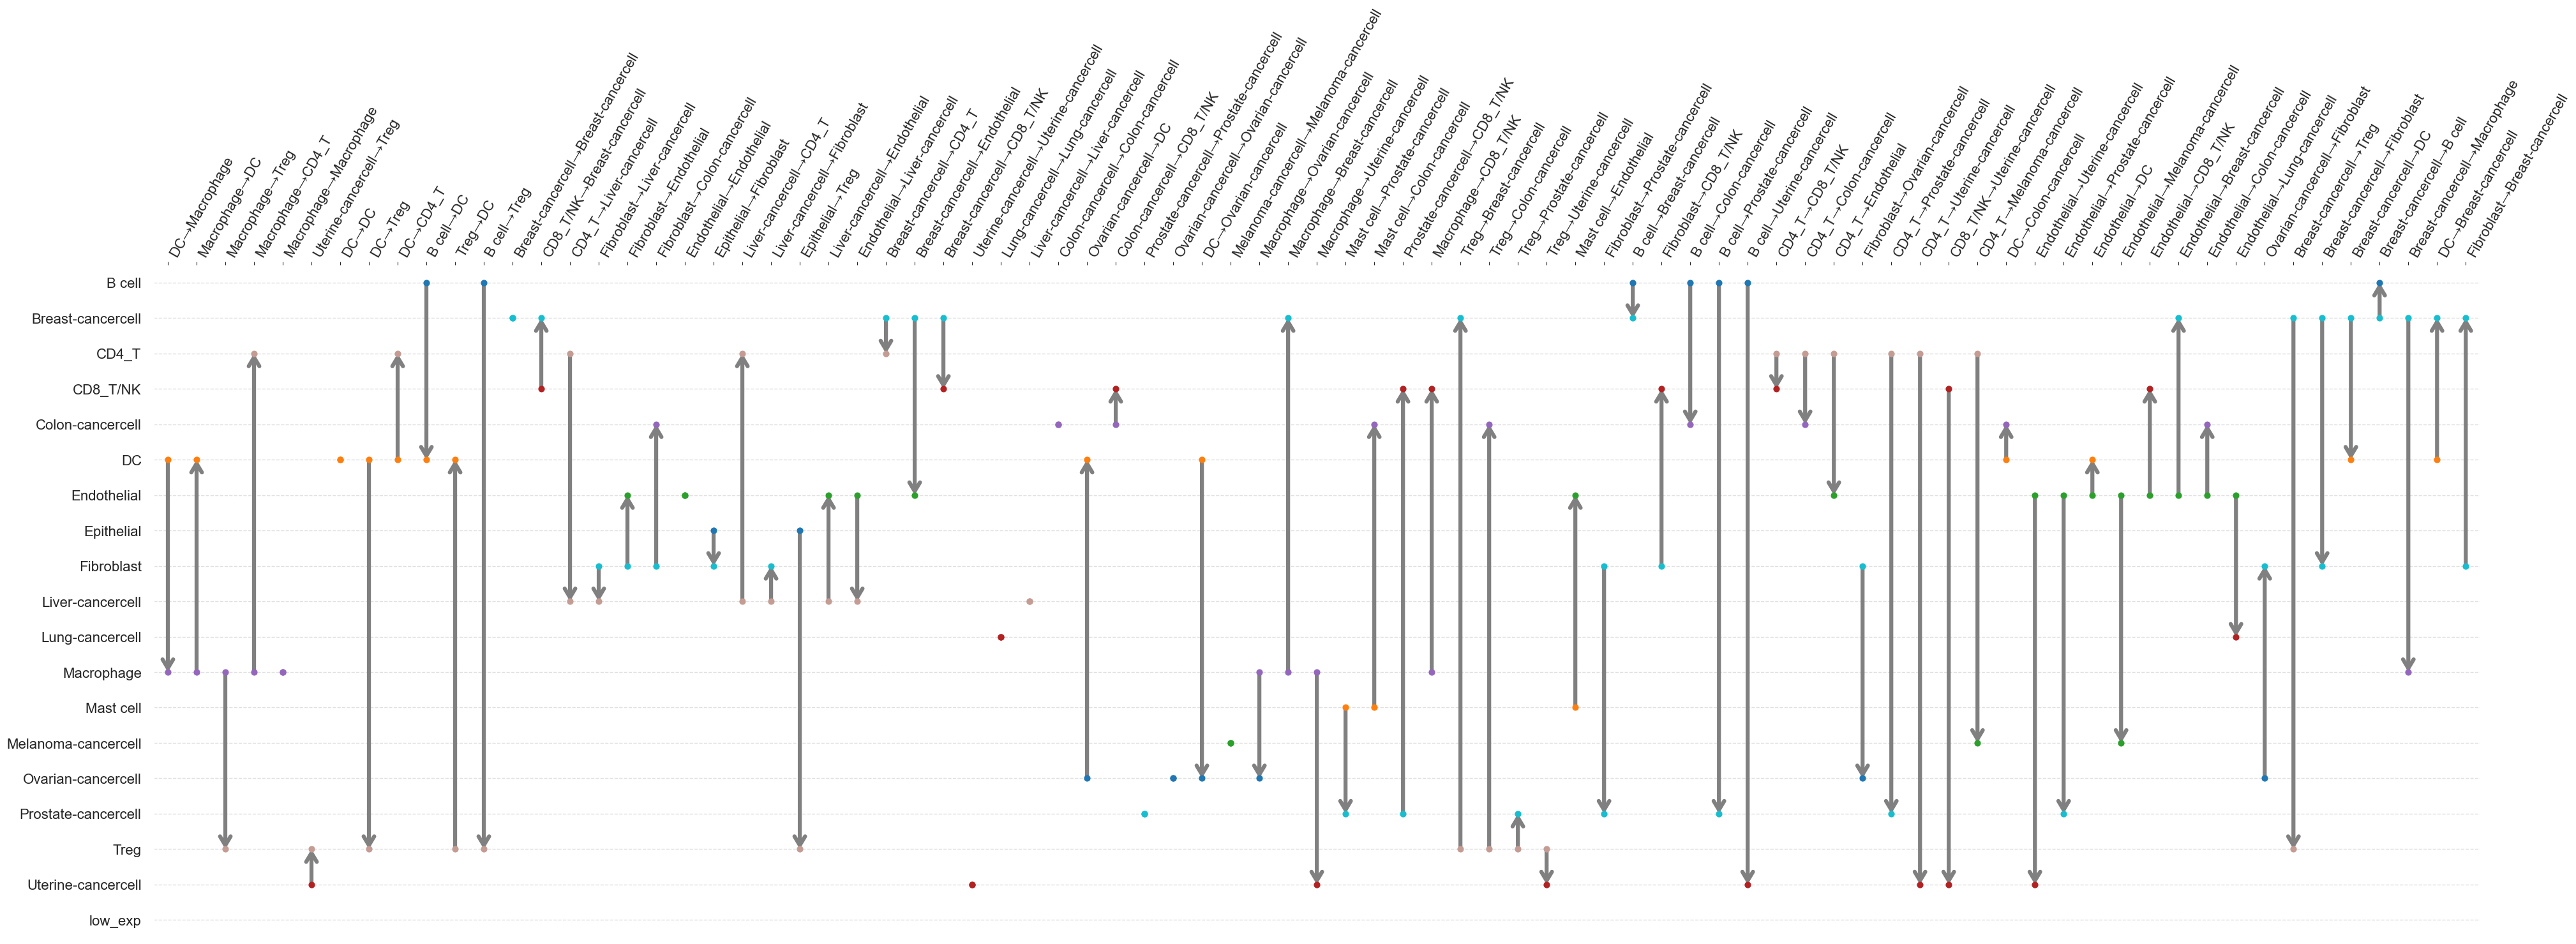

D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\SpiderNet\analysis.py:1043: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.6837649345397949' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Avg_MI_cellclass_pair_merge_zscored_ctagg_sender.iloc[idx, :] = list(
D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\SpiderNet\analysis.py:1043: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5467859506607056' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  Avg_MI_cellclass_pair_merge_zscored_ctagg_sender.iloc[idx, :] = list(
D:\SpiderNet\SpiderNet_proj\SpiderNet_Project\SpiderNet\analysis.py:1043: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.5133653283119202' has dtype inc

{'Avg_MI_cellclass_pair_merge_use_csv': 'D:\\SpiderNet\\Results\\Pancancer\\V1\\SpiderNet_Result_dim11\\Avg_MI_cellclass_pair_merge_use.csv',
 'Avg_MI_cellclass_pair_png': 'D:\\SpiderNet\\Results\\Pancancer\\V1\\SpiderNet_Result_dim11\\Avg_MI_cellclass_pair.png',
 'Avg_MI_cellclass_pair_onlymalignant_png': 'D:\\SpiderNet\\Results\\Pancancer\\V1\\SpiderNet_Result_dim11\\Avg_MI_cellclass_pair_onlymalignant_highlight.png',
 'Sender_vs_Receiver_scatter_png': 'D:\\SpiderNet\\Results\\Pancancer\\V1\\SpiderNet_Result_dim11\\Sender_vs_Receiver_MI_Strength.png',
 'Celltype_pair_example_png': 'D:\\SpiderNet\\Results\\Pancancer\\V1\\SpiderNet_Result_dim11\\Celltype_pair_example.png',
 'Agg_heatmap_png': 'D:\\SpiderNet\\Results\\Pancancer\\V1\\SpiderNet_Result_dim11\\Avg_MI_cellclass_pair_agg.png',
 'Site_dotplot_png': None,
 'Site_dotplot_top_hits_csv': None,
 'Agg_sender_receiver_csv': 'D:\\SpiderNet\\Results\\Pancancer\\V1\\SpiderNet_Result_dim11\\Avg_MI_cellclass_pair_merge_zscored_ctagg.csv',

In [17]:
from SpiderNet.analysis import MI_Celltypepair_enrichment
MI_Celltypepair_enrichment(
    SpiderNet_data_pyg_list_path=run_dirs['run_dir'] / "SpiderNet_data_pyg_list.pkl",
    Factor_envir_use_path=run_dirs['run_dir'] / "Factor_envir_use.npy",
    file_savepath_main=run_dirs['run_dir'],
    metadata_sample_path="None",
    LR_loading_pathway_path=run_dirs['run_dir'] / "LR_loading_pathway.csv",
    dim_envir=train_cfg.dim_envir,
    MIlevel_agg_threshold=0.6,
    batch_cell_unique_path=run_dirs['run_dir'] / "batch_cell_unique.pkl",
    adata_list_path=run_dirs['run_dir'] / "adata_list.pkl",
    adata_copy_path=run_dirs['run_dir'] / "adata_all.h5ad",
    show=True
)


## Adapting this notebook to your own data

Start by editing the dataset setup cell.

What usually changes:
- data paths
- species
- `SAMPLE_ID_COL`, `CELL_TYPE_COL`, `SPATIAL_KEY`
- preprocessing parameters
- training parameters

Recommended order:
1. edit the dataset setup cell
2. run the path / AnnData check
3. preprocess
4. check outputs
5. train and export


In [18]:
# processed.adata_list[0].obs['SampleID']
# adata_i.obs